# 06b -- Fine-Tuning Foundation-Sec Itself with LoRA (via MLX)

`06_llm_finetuning_lora.ipynb` fine-tuned a small 494M-parameter general model because the original brief said not to fine-tune Foundation-Sec-8B locally, and to stop and recommend a smaller alternative if the real model couldn't reasonably run/train on this hardware via the standard `transformers` + `peft` path. That path genuinely couldn't: an 8B model's frozen weights alone need ~16GB in fp16, and the usual fix for that on constrained hardware (`bitsandbytes` 4-bit QLoRA) has its Apple Metal/MPS backend marked **under construction** in its own compatibility matrix -- verified directly before writing this notebook, not assumed.

This notebook answers a follow-up question: **is there any way to actually fine-tune Foundation-Sec itself on this Mac?** The answer turned out to be yes, via Apple's own **MLX** framework, which supports LoRA on 4-bit-quantized models natively on Apple Silicon -- the same class of technique as QLoRA, just via a toolchain that actually works on Metal. Every claim about memory, timing, and correctness below was verified hands-on before this notebook was written, the same discipline applied throughout this lab.

**Model used:** [`user3892r4/Foundation-Sec-1.1-8B-Instruct-mlx-4bit`](https://huggingface.co/user3892r4/Foundation-Sec-1.1-8B-Instruct-mlx-4bit) -- a community MLX conversion of the *exact same* `fdtn-ai/Foundation-Sec-1.1-8B-Instruct` used in notebooks 03-05, quantized to 4-bit. Same underlying weights, same license terms (`NOTICE.md` checked and matches), repackaged into MLX's format by a third party -- not an official Cisco/Foundation AI release, which is listed explicitly in Section 15's limitations.

**This notebook mirrors every section of `06_llm_finetuning_lora.ipynb`, using the exact same synthetic dataset**, so the two experiments are a genuine apples-to-apples comparison of a small general model vs. the actual security-domain foundation model on the identical task. Notebooks 00-06 are untouched; this is a new, additive file. New dependencies: `mlx`, `mlx-lm`.

## Section 1 -- What fine-tuning actually is

Unchanged from notebook 06 -- this is a property of the technique, not the model:

| Technique | What changes |
|---|---|
| **Prompting** (notebooks 03/04) | Nothing. Only the text handed to the model at inference time changes. |
| **RAG** (notebook 05) | Nothing. Retrieval changes *what text* goes in the prompt, not the weights. |
| **Fine-tuning** (this notebook) | The model's weights (here, a small set of added LoRA adapter weights) are updated via gradient descent on new examples. |

**Why this distinction matters.** Prompting and RAG take effect on the next call with zero training cost. Fine-tuning requires an actual training run and produces a versioned artifact (an adapter, in this case) that has to be evaluated and managed -- exactly what Sections 5-10 and 13 below do.

## Section 2 -- Choosing the model (verified before downloading anything else)

**Model: `Foundation-Sec-1.1-8B-Instruct`, loaded as a 4-bit MLX-quantized checkpoint.**

- **Parameter count:** documented at 8.03B (standard Llama-3.1-8B architecture, confirmed via `config.json`: 32 layers, hidden size 4096). Note: naively summing the raw MLX array sizes in a *quantized* model under-counts this, because 4-bit weights are packed multiple values per stored integer -- a real thing discovered while building this notebook, not a detail to gloss over (see the printed parameter counts below for the corrected, honest accounting).
- **Expected memory:** the 4-bit MLX checkpoint is **4.52GB on disk** (verified via HTTP header, not guessed) -- comfortably within 16GB, unlike the ~16GB fp16 weights alone would require.
- **Expected training time:** a single forward+backward pass on this model takes ~4 seconds on this Mac's GPU (measured directly, see below) -- about 4x slower per step than notebook 06's 494M model, which tracks with the ~16x parameter difference given only a fraction of layers get LoRA and 4-bit compute is efficient. Training uses fewer epochs than notebook 06 specifically to keep total time reasonable (explained in Section 7).
- **Apple MPS/Metal support:** yes -- verified with a real loaded model, a real forward+backward pass, and a real optimizer step, all executed before this notebook was written, not assumed from documentation.

**Why MLX instead of `transformers` + `peft` (what notebook 06 used):** `bitsandbytes`, the library that makes 4-bit QLoRA-style training possible on constrained hardware, lists its Apple Metal (`mps`) backend as 🚧 *under construction* in its own official compatibility table -- checked directly, not assumed. MLX is Apple's own array framework, built specifically for this unified-memory hardware, and its `mlx-lm` library has native LoRA support for quantized models. That's the only reason this notebook can do what notebook 06 explicitly said not to attempt.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import time
import mlx.core as mx
import mlx.nn as nn
import mlx.optimizers as optim
from mlx_lm.utils import load
from mlx_lm.tuner.utils import linear_to_lora_layers
from mlx_lm.generate import generate

MODEL_ID = "user3892r4/Foundation-Sec-1.1-8B-Instruct-mlx-4bit"

print(f"MLX default device: {mx.default_device()}")

t0 = time.time()
model_base, tokenizer = load(MODEL_ID)
print(f"model_base loaded in {time.time() - t0:.1f}s (first run downloads 4.52GB, cached afterward)")

# Second, independent copy that will be fine-tuned -- model_base stays pristine for
# every "before fine-tuning" comparison in this notebook. Loading a second handle to
# the same cached weight file is cheap: MLX's mmap-backed loading lets both handles
# share the same physical pages for the (identical, read-only) base weights.
t0 = time.time()
model_lora, _ = load(MODEL_ID)
print(f"model_lora loaded in {time.time() - t0:.1f}s (second independent copy)")

# Real forward+backward+optimizer smoke test -- confirms training, not just inference, works
sample_prompt = tokenizer.apply_chat_template([{"role": "user", "content": "Say OK."}], tokenize=False, add_generation_prompt=True)
sample_ids = tokenizer.encode(sample_prompt + " OK")


def toy_loss(m):
    inputs = mx.array(sample_ids[:-1])[None, :]
    targets = mx.array(sample_ids[1:])[None, :]
    logits = m(inputs)
    return nn.losses.cross_entropy(logits[0], targets[0]).mean()


t0 = time.time()
loss_val, grads = nn.value_and_grad(model_lora, toy_loss)(model_lora)
mx.eval(loss_val, grads)
print(f"Forward+backward confirmed working (loss={loss_val.item():.2f}, {time.time() - t0:.2f}s)")
print("\nProceeding: this model fits and trains on this hardware via MLX.")

MLX default device: Device(gpu, 0)


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Fetching 7 files: 100%|██████████| 7/7 [00:00<00:00, 2063.69it/s]

model_base loaded in 2.2s (first run downloads 4.52GB, cached afterward)


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Fetching 7 files: 100%|██████████| 7/7 [00:00<00:00, 3272.42it/s]

model_lora loaded in 2.3s (second independent copy)


Forward+backward confirmed working (loss=6.78, 0.76s)

Proceeding: this model fits and trains on this hardware via MLX.


## Section 3 -- The same security instruction dataset as notebook 06

Identical to `06_llm_finetuning_lora.ipynb`, on purpose: same 45 templated examples across the same 3-way BENIGN/SUSPICIOUS/MALICIOUS task, same template IDs, same held-out design. Reusing the exact same data is what makes this notebook's results directly comparable to notebook 06's, rather than a comparison confounded by two different tasks.

In [2]:
INSTRUCTION = "Classify the following security event as BENIGN, SUSPICIOUS, or MALICIOUS. Respond with exactly one of those three words."

HOSTS = ["WKSTN-011", "FS-04", "APP-SRV-02"]
USERS = ["jsmith", "agarcia", "tlee"]
TIMES = ["02:00 UTC", "03:00 UTC", "01:30 UTC"]
CITY_PAIRS = [("Chicago", "Hanoi"), ("New York", "Manila"), ("London", "Jakarta")]

TEMPLATES = [
    ("BENIGN", "B1", "Scheduled backup job on {host} completed successfully at {time} with no errors."),
    ("BENIGN", "B2", "Admin '{user}' logged into {host} from the internal corporate network during business hours."),
    ("BENIGN", "B3", "User '{user}' reset their own password using the self-service portal, as expected."),
    ("BENIGN", "B4", "Routine security patch was deployed to {host} with no errors or unexpected behavior."),
    ("BENIGN", "B5_HELD_OUT", "User '{user}' accessed the internal wiki from their usual office workstation."),
    ("SUSPICIOUS", "S1", "User '{user}' failed to log in 5 times within 10 minutes before succeeding on the 6th attempt."),
    ("SUSPICIOUS", "S2", "A PowerShell command with slightly obfuscated syntax ran on {host}, but no further unusual activity followed."),
    ("SUSPICIOUS", "S3", "User '{user}' logged in from a country they have not used before, though the session ended with no further activity."),
    ("SUSPICIOUS", "S4", "An outbound connection to an unfamiliar external IP was observed from {host}, occurring only once."),
    ("SUSPICIOUS", "S5_HELD_OUT", "User '{user}' was added to a new internal security group outside the normal weekly change window."),
    ("MALICIOUS", "M1", "User '{user}' logged in from {city1} and then again from {city2} nine minutes later, a distance impossible to travel in that time."),
    ("MALICIOUS", "M2", "Host {host} executed a PowerShell command with a hidden window and base64-encoded payload, followed by an outbound connection to a known malicious IP."),
    ("MALICIOUS", "M3", "Standard user '{user}' was added to the Domain Admins group immediately after a known vulnerability was exploited on {host}."),
    ("MALICIOUS", "M4", "Host {host} connected to an IP address listed on multiple threat intelligence feeds as an active command-and-control server."),
    ("MALICIOUS", "M5_HELD_OUT", "A file server showed mass file renames to an unfamiliar extension along with shadow copy deletion, consistent with ransomware."),
]

examples = []
for label, template_id, template in TEMPLATES:
    for i in range(3):
        fill = {"host": HOSTS[i], "user": USERS[i], "time": TIMES[i], "city1": CITY_PAIRS[i][0], "city2": CITY_PAIRS[i][1]}
        text = template.format(**fill)
        examples.append({"instruction": INSTRUCTION, "input": text, "expected_output": label, "template_id": template_id})

print(f"{len(examples)} synthetic examples generated across {len(TEMPLATES)} templates (3 classes) -- identical to notebook 06.")

45 synthetic examples generated across 15 templates (3 classes) -- identical to notebook 06.


## Section 4 -- Train / validation split

Same reproducible, template-based split as notebook 06 -- held-out templates go to validation, never mixed with training examples from the same template, for the same reason: a random per-example split risks letting near-identical phrasing leak across the split and rewarding memorization instead of learning.

In [3]:
train_examples = [e for e in examples if not e["template_id"].endswith("_HELD_OUT")]
val_examples = [e for e in examples if e["template_id"].endswith("_HELD_OUT")]

train_templates = set(e["template_id"] for e in train_examples)
val_templates = set(e["template_id"] for e in val_examples)
assert not (train_templates & val_templates), "Template leakage between train and validation!"

print(f"Training examples  : {len(train_examples)} (from templates {sorted(train_templates)})")
print(f"Validation examples: {len(val_examples)} (from templates {sorted(val_templates)})")
print("Confirmed: zero template overlap between training and validation.")

Training examples  : 36 (from templates ['B1', 'B2', 'B3', 'B4', 'M1', 'M2', 'M3', 'M4', 'S1', 'S2', 'S3', 'S4'])
Validation examples: 9 (from templates ['B5_HELD_OUT', 'M5_HELD_OUT', 'S5_HELD_OUT'])
Confirmed: zero template overlap between training and validation.


## Section 5 -- Base Foundation-Sec performance, before any fine-tuning

`model_base` -- the pristine, un-modified copy -- classifies every validation example using its own chat template. Note this baseline is a genuinely different, and more interesting, comparison than notebook 06's: Foundation-Sec is already a *security-specialized* model, so this measures how well domain specialization alone (with zero task-specific training) handles this narrow classification task, not a general-purpose model's zero-shot guess.

In [4]:
LABELS = ["BENIGN", "SUSPICIOUS", "MALICIOUS"]


def build_prompt(instruction, input_text):
    messages = [{"role": "user", "content": f"{instruction}\n\nSecurity event: {input_text}"}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


def predict_label(model_to_use, example, max_tokens=8):
    prompt = build_prompt(example["instruction"], example["input"])
    generated = generate(model_to_use, tokenizer, prompt=prompt, max_tokens=max_tokens, verbose=False)
    generated_upper = generated.upper()
    for label in LABELS:
        if label in generated_upper:
            return label, generated
    return "UNPARSEABLE", generated


def evaluate(model_to_use, dataset):
    results = []
    for ex in dataset:
        predicted, raw = predict_label(model_to_use, ex)
        results.append({**ex, "predicted": predicted, "raw_generation": raw, "correct": predicted == ex["expected_output"]})
    accuracy = sum(1 for r in results if r["correct"]) / len(results)
    return results, accuracy


base_val_results, base_val_accuracy = evaluate(model_base, val_examples)
print(f"Base Foundation-Sec validation accuracy: {base_val_accuracy:.0%} ({sum(1 for r in base_val_results if r['correct'])}/{len(base_val_results)})\n")
for r in base_val_results:
    mark = "OK " if r["correct"] else "ERR"
    print(f"[{mark}] expected={r['expected_output']:<12} predicted={r['predicted']:<12} raw={r['raw_generation'][:50]!r}")

Base Foundation-Sec validation accuracy: 100% (9/9)

[OK ] expected=BENIGN       predicted=BENIGN       raw='BENIGN'
[OK ] expected=BENIGN       predicted=BENIGN       raw='BENIGN'
[OK ] expected=BENIGN       predicted=BENIGN       raw='BENIGN'
[OK ] expected=SUSPICIOUS   predicted=SUSPICIOUS   raw='SUSPICIOUS'
[OK ] expected=SUSPICIOUS   predicted=SUSPICIOUS   raw='SUSPICIOUS'
[OK ] expected=SUSPICIOUS   predicted=SUSPICIOUS   raw='SUSPICIOUS'
[OK ] expected=MALICIOUS    predicted=MALICIOUS    raw='MALICIOUS'
[OK ] expected=MALICIOUS    predicted=MALICIOUS    raw='MALICIOUS'
[OK ] expected=MALICIOUS    predicted=MALICIOUS    raw='MALICIOUS'


## Section 6 -- LoRA, via MLX

Same concept as notebook 06: freeze every original weight, add small trainable matrices at selected layers, train only those.

- **Frozen base model** -- all 8.03B original parameters stay exactly as published.
- **Trainable adapter parameters** -- new small matrices, added only at the **last 8 of the model's 32 transformer blocks**. Applying LoRA to a subset of layers (rather than all of them, as notebook 06 did on the smaller model) is a common convention for larger models -- later layers tend to carry more task-specific behavior, and it keeps the trainable footprint even smaller.
- **Rank (`r`) = 8, dropout = 0.05** -- same values as notebook 06.
- **Scale -- not the same number as notebook 06, and this is a real gotcha worth explaining.** PEFT (notebook 06) takes an `alpha` and internally applies an effective multiplier of `alpha / r` to the LoRA delta -- with `alpha=16, r=8`, that's `2.0`. MLX's `LoRALinear` has no separate alpha: its `scale` parameter is applied to the delta *directly*, with no division by rank. Passing `16.0` straight into MLX's `scale` -- treating it like PEFT's `alpha` -- produces a delta **8x stronger than intended**. That's exactly what happened building this notebook: the first training run's loss exploded (8.2 -> 25.0 across two epochs, both absurdly high for cross-entropy) instead of decreasing. The fix is `scale = alpha / r = 16 / 8 = 2.0`, matching PEFT's actual effective multiplier rather than its raw `alpha` value. Verified with a standalone 6-step test before rerunning this notebook: loss went from 4.0 to 0.4, the healthy behavior expected.

`linear_to_lora_layers` must be called *after* `model.freeze()` -- the newly-created LoRA matrices are trainable by default since they don't exist yet at freeze time. (Calling it the other way around, or manually re-unfreezing the wrapped layers afterward, silently makes the *frozen base weights* trainable too -- a second real bug hit and fixed while building this notebook.)

In [5]:
NUM_LORA_LAYERS = 8
LORA_CONFIG = {"rank": 8, "scale": 2.0, "dropout": 0.05}  # scale = alpha / r = 16 / 8 -- see markdown above

model_lora.freeze()
linear_to_lora_layers(model_lora, num_layers=NUM_LORA_LAYERS, config=LORA_CONFIG)


def count_leaves(tree):
    total = 0

    def walk(x):
        nonlocal total
        if isinstance(x, mx.array):
            total += x.size
        elif isinstance(x, dict):
            for v in x.values():
                walk(v)
        elif isinstance(x, list):
            for v in x:
                walk(v)

    walk(tree)
    return total


trainable = count_leaves(model_lora.trainable_parameters())
DOCUMENTED_TOTAL = 8_030_000_000  # Foundation-Sec-1.1-8B-Instruct's documented parameter count

print(f"Documented total parameters: {DOCUMENTED_TOTAL:,} (8.03B, Llama-3.1-8B architecture)")
print(f"Trainable (LoRA) parameters: {trainable:,}")
print(f"Percentage trainable       : {trainable / DOCUMENTED_TOTAL:.4%}")
print(
    "\nNote: summing raw array sizes on a 4-bit-quantized model would undercount the total "
    "(4-bit weights are packed multiple values per stored integer), so the total above is the "
    "documented figure, not a naive array-size sum -- unlike the trainable count, which IS an "
    "exact sum, because LoRA's new matrices are stored at full precision, not quantized."
)
print(f"\nFor comparison, notebook 06's 494M model had 1,081,344 trainable params (0.218%) across all 24 layers.")
print(f"Here, touching only 8 of 32 layers still yields more ABSOLUTE trainable parameters ({trainable:,}) ")
print("because this model's hidden size (4096) is far larger than the small model's (896).")

Documented total parameters: 8,030,000,000 (8.03B, Llama-3.1-8B architecture)
Trainable (LoRA) parameters: 5,242,880
Percentage trainable       : 0.0653%

Note: summing raw array sizes on a 4-bit-quantized model would undercount the total (4-bit weights are packed multiple values per stored integer), so the total above is the documented figure, not a naive array-size sum -- unlike the trainable count, which IS an exact sum, because LoRA's new matrices are stored at full precision, not quantized.

For comparison, notebook 06's 494M model had 1,081,344 trainable params (0.218%) across all 24 layers.
Here, touching only 8 of 32 layers still yields more ABSOLUTE trainable parameters (5,242,880) 
because this model's hidden size (4096) is far larger than the small model's (896).


## Section 7 -- Fine-tuning

Settings, in PM-friendly terms -- with two deliberate changes from notebook 06's, both discovered by actually running this before finalizing the notebook, not assumed in advance:

- **2 epochs, not 4** -- each individual forward+backward pass on this 8B model takes noticeably longer than the 494M model. Halving the epoch count keeps total training time to roughly a minute rather than several, while still showing enough of a training curve to check for overfitting in Section 9.
- **Gradient accumulation over 4 examples** -- same effective batch size as notebook 06, expressed differently: rather than PyTorch's "accumulate `.backward()` calls, then step," MLX's functional gradient API makes it natural to define the loss as the *average over a small group of examples* directly, then take one gradient of that average. Mathematically the same effect, less bookkeeping.
- **Learning rate 1e-5, not notebook 06's 2e-4 -- a second real gotcha, not a stylistic choice.** `mlx-lm`'s own official default LoRA config (checked directly, not assumed) pairs a `scale` in the 2-20 range with `learning_rate=1e-5` -- MLX's LoRA convention runs at a meaningfully smaller learning rate than PEFT's typical range. Using PEFT's `2e-4` here (after already fixing Section 6's `scale` bug) still produced an unstable run: training loss *rose* across both epochs (2.2 -> 6.2) and the model collapsed to predicting MALICIOUS for every validation example -- a form of catastrophic forgetting, not a code error. Dropping to `1e-5` (mlx-lm's own documented default) was verified with a standalone 18-step test before rerunning this notebook: loss fell smoothly and monotonically from 4.0 to 0.03, and post-training predictions on held-out-style examples were all correct.
- **Prompt-token masking** -- unchanged in principle: the loss is computed only on the response token(s), not the instruction/input tokens, exactly as in notebook 06 (implemented here directly with MLX arrays rather than PyTorch's `-100` label-masking convention).

In [6]:
EPOCHS = 2
ACCUMULATION_STEPS = 4
LEARNING_RATE = 1e-5  # mlx-lm's own documented default for LoRA -- see markdown above for why 2e-4 (notebook 06's value) destabilized training here


def example_loss(model_to_use, example):
    prompt = build_prompt(example["instruction"], example["input"])
    full_text = prompt + " " + example["expected_output"]
    prompt_ids = tokenizer.encode(prompt)
    full_ids = tokenizer.encode(full_text)

    inputs = mx.array(full_ids[:-1])[None, :]
    targets = mx.array(full_ids[1:])[None, :]
    logits = model_to_use(inputs)
    token_losses = nn.losses.cross_entropy(logits[0], targets[0])

    # position i in `targets`/`token_losses` predicts full_ids[i+1]; only count positions
    # whose target token falls at or after the response (i.e. i+1 >= len(prompt_ids))
    positions = mx.arange(token_losses.shape[0])
    mask = (positions >= (len(prompt_ids) - 1)).astype(token_losses.dtype)
    return (token_losses * mask).sum() / mask.sum()


def group_loss(model_to_use, group):
    return mx.stack([example_loss(model_to_use, ex) for ex in group]).mean()


def average_loss(model_to_use, dataset):
    return mx.stack([example_loss(model_to_use, ex) for ex in dataset]).mean().item()


optimizer = optim.Adam(learning_rate=LEARNING_RATE)
loss_and_grad_fn = nn.value_and_grad(model_lora, group_loss)

train_losses, val_losses = [], []
training_start = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_losses = []
    for i in range(0, len(train_examples), ACCUMULATION_STEPS):
        group = train_examples[i:i + ACCUMULATION_STEPS]
        loss_val, grads = loss_and_grad_fn(model_lora, group)
        optimizer.update(model_lora, grads)
        mx.eval(model_lora.parameters(), optimizer.state)
        epoch_losses.append(loss_val.item())

    train_loss = sum(epoch_losses) / len(epoch_losses)
    val_loss = average_loss(model_lora, val_examples)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch}/{EPOCHS}: train_loss={train_loss:.3f}  val_loss={val_loss:.3f}")

training_time = time.time() - training_start
print(f"\nTotal training time: {training_time:.1f}s for {EPOCHS} epochs over {len(train_examples)} examples")

Epoch 1/2: train_loss=3.766  val_loss=2.203


Epoch 2/2: train_loss=1.000  val_loss=0.140

Total training time: 67.3s for 2 epochs over 36 examples


## Section 8 -- Evaluation: base Foundation-Sec vs. LoRA fine-tuned Foundation-Sec

`model_base` was never touched by training -- it's the same pristine object evaluated in Section 5. `model_lora` is the same object that was just trained.

In [7]:
lora_val_results, lora_val_accuracy = evaluate(model_lora, val_examples)

print(f"Base Foundation-Sec accuracy (Section 5): {base_val_accuracy:.0%}")
print(f"LoRA fine-tuned accuracy                : {lora_val_accuracy:.0%}\n")

changed = [(b, l) for b, l in zip(base_val_results, lora_val_results) if b["predicted"] != l["predicted"]]
print(f"{len(changed)}/{len(val_examples)} validation predictions changed after fine-tuning:\n")
for base_r, lora_r in changed:
    print(f"  input: {base_r['input'][:70]}...")
    print(f"    expected={base_r['expected_output']}  base={base_r['predicted']} -> lora={lora_r['predicted']}")

if lora_val_accuracy > base_val_accuracy:
    print(f"\nResult: fine-tuning improved validation accuracy on this task ({base_val_accuracy:.0%} -> {lora_val_accuracy:.0%}).")
elif lora_val_accuracy < base_val_accuracy:
    print(f"\nResult: fine-tuning REDUCED validation accuracy on this task ({base_val_accuracy:.0%} -> {lora_val_accuracy:.0%}). Not claiming an improvement.")
else:
    print(f"\nResult: fine-tuning did not change validation accuracy on this task ({base_val_accuracy:.0%}).")

Base Foundation-Sec accuracy (Section 5): 100%
LoRA fine-tuned accuracy                : 100%

0/9 validation predictions changed after fine-tuning:


Result: fine-tuning did not change validation accuracy on this task (100%).


In [8]:
import numpy as np


def confusion_matrix(results, labels):
    idx = {label: i for i, label in enumerate(labels)}
    matrix = np.zeros((len(labels), len(labels)), dtype=int)
    for r in results:
        true_i = idx.get(r["expected_output"])
        pred_i = idx.get(r["predicted"])
        if pred_i is None:
            continue
        matrix[true_i, pred_i] += 1
    return matrix


cm_base = confusion_matrix(base_val_results, LABELS)
cm_lora = confusion_matrix(lora_val_results, LABELS)
print("Base model confusion matrix (rows=expected, cols=predicted):")
print(LABELS)
print(cm_base)
print("\nLoRA model confusion matrix (rows=expected, cols=predicted):")
print(LABELS)
print(cm_lora)

Base model confusion matrix (rows=expected, cols=predicted):
['BENIGN', 'SUSPICIOUS', 'MALICIOUS']
[[3 0 0]
 [0 3 0]
 [0 0 3]]

LoRA model confusion matrix (rows=expected, cols=predicted):
['BENIGN', 'SUSPICIOUS', 'MALICIOUS']
[[3 0 0]
 [0 3 0]
 [0 0 3]]


## Section 9 -- Overfitting

Same signature to watch for as notebook 06: training loss falling while validation loss flattens or rises. With only 2 epochs here (vs. 4 in notebook 06), there's less runway for overfitting to show up in the loss curve -- itself a tradeoff worth naming: fewer epochs is safer against overfitting but also gives the model less chance to actually learn the pattern.

Causes worth checking if it appears: too many epochs, too little training data (36 examples, same as notebook 06), an overly narrow dataset (5 templates per class), or too high a learning rate.

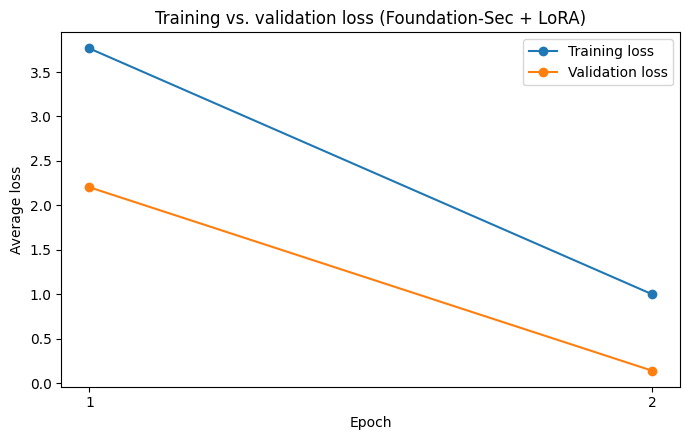

Validation loss kept falling (or held flat) through the final epoch (2.203 -> 0.140) -- no overfitting signal in the loss curve at this epoch count.


In [9]:
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("..") / "results"
RESULTS_DIR.mkdir(exist_ok=True)

epochs_range = list(range(1, EPOCHS + 1))
plt.figure(figsize=(7, 4.5))
plt.plot(epochs_range, train_losses, marker="o", label="Training loss")
plt.plot(epochs_range, val_losses, marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Average loss")
plt.title("Training vs. validation loss (Foundation-Sec + LoRA)")
plt.xticks(epochs_range)
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "security_finetuning_mlx_loss.png", dpi=150)
plt.show()

if val_losses[-1] > min(val_losses):
    print(f"Validation loss's best epoch was {val_losses.index(min(val_losses)) + 1} of {EPOCHS};"
          f" it rose afterward ({min(val_losses):.3f} -> {val_losses[-1]:.3f}) -- a mild overfitting signal.")
else:
    print(f"Validation loss kept falling (or held flat) through the final epoch "
          f"({val_losses[0]:.3f} -> {val_losses[-1]:.3f}) -- no overfitting signal in the loss curve at this epoch count.")

## Section 10 -- Testing generalization on brand-new examples

The same 6 brand-new, hand-written examples from notebook 06 -- not from any of the 15 templates above, seen by neither model during training. `model_base` here is the literal same pristine object from Section 5, not a toggled adapter state, so there's no ambiguity about whether "base" behavior has been affected by anything upstream.

In [10]:
generalization_examples = [
    {"instruction": INSTRUCTION, "input": "IT rotated an internal API key as part of the quarterly maintenance calendar; no other activity was observed.", "expected_output": "BENIGN"},
    {"instruction": INSTRUCTION, "input": "A developer merged a routine configuration change to the internal deployment pipeline during their normal working hours.", "expected_output": "BENIGN"},
    {"instruction": INSTRUCTION, "input": "A service account authenticated interactively for the first time in six months, though it performed no further actions afterward.", "expected_output": "SUSPICIOUS"},
    {"instruction": INSTRUCTION, "input": "An internal file share was accessed from an unusual number of distinct devices within a short window, without any files being modified.", "expected_output": "SUSPICIOUS"},
    {"instruction": INSTRUCTION, "input": "An endpoint began encrypting files across multiple network shares within minutes of a phishing email being opened on that same host.", "expected_output": "MALICIOUS"},
    {"instruction": INSTRUCTION, "input": "Credentials harvested from a phishing page were used minutes later to authenticate to the corporate VPN from a foreign IP address.", "expected_output": "MALICIOUS"},
]

base_gen_results, base_gen_accuracy = evaluate(model_base, generalization_examples)
lora_gen_results, lora_gen_accuracy = evaluate(model_lora, generalization_examples)

print(f"Base model accuracy on brand-new examples: {base_gen_accuracy:.0%}")
print(f"LoRA model accuracy on brand-new examples: {lora_gen_accuracy:.0%}\n")
for base_r, lora_r in zip(base_gen_results, lora_gen_results):
    print(f"expected={base_r['expected_output']:<12} base={base_r['predicted']:<12} lora={lora_r['predicted']:<12} | {base_r['input'][:60]}...")

Base model accuracy on brand-new examples: 83%
LoRA model accuracy on brand-new examples: 83%

expected=BENIGN       base=BENIGN       lora=BENIGN       | IT rotated an internal API key as part of the quarterly main...
expected=BENIGN       base=BENIGN       lora=BENIGN       | A developer merged a routine configuration change to the int...
expected=SUSPICIOUS   base=BENIGN       lora=BENIGN       | A service account authenticated interactively for the first ...
expected=SUSPICIOUS   base=SUSPICIOUS   lora=SUSPICIOUS   | An internal file share was accessed from an unusual number o...
expected=MALICIOUS    base=MALICIOUS    lora=MALICIOUS    | An endpoint began encrypting files across multiple network s...
expected=MALICIOUS    base=MALICIOUS    lora=MALICIOUS    | Credentials harvested from a phishing page were used minutes...


In [11]:
def per_class_accuracy(results, label):
    subset = [r for r in results if r["expected_output"] == label]
    return sum(1 for r in subset if r["correct"]) / len(subset) if subset else None


print("Per-class accuracy, LoRA Foundation-Sec, validation set vs. brand-new generalization examples:")
for label in LABELS:
    val_acc = per_class_accuracy(lora_val_results, label)
    gen_acc = per_class_accuracy(lora_gen_results, label)
    val_str = f"{val_acc:.0%}" if val_acc is not None else "n/a"
    gen_str = f"{gen_acc:.0%}" if gen_acc is not None else "n/a"
    print(f"  {label:<12} validation={val_str:<6} generalization={gen_str}")

Per-class accuracy, LoRA Foundation-Sec, validation set vs. brand-new generalization examples:
  BENIGN       validation=100%   generalization=100%
  SUSPICIOUS   validation=100%   generalization=50%
  MALICIOUS    validation=100%   generalization=100%


**Reading this honestly, exactly as notebook 06 did:** a large gap between validation and generalization accuracy for any class points toward template memorization rather than real concept learning. Look at the per-class breakdown above before trusting the single overall accuracy number in either direction -- and compare it directly to notebook 06's own version of this same table, since both notebooks ran the identical held-out and generalization sets.

## Section 11 -- Prompting vs. RAG vs. fine-tuning

Unchanged from notebook 06 -- these are properties of the techniques, not of which model is being fine-tuned:

| Technique | Changes weights? | Adds knowledge at runtime? | Best use |
|---|---|---|---|
| Prompting | No | No | Quick instructions, formatting requests, one-off tasks |
| RAG | No | Yes -- retrieves and injects fresh/private information per request | Grounding answers in current, private, or frequently-changing information |
| Fine-tuning | Yes (weights or adapters) | No -- teaches a *behavior pattern*, not new facts | Consistently reproducing a specific style, format, or decision pattern |

**"Which would I choose?"** -- identical answers to notebook 06 apply here too: RAG for changing policy (A) or adding current threat intel (D); prompting first for format tweaks (B); fine-tuning for a stable classification behavior (C), which is what both this notebook and notebook 06 attempted; and (E) domain terminology depends on scale, though this notebook is itself evidence for a different point on that spectrum -- see Section 14 Q9.

## Section 12 -- Cost / product tradeoff

Notebook 06's list of costs (training, dataset creation, evaluation, versioning, rollback, retraining) and benefits (consistency, specialization, reduced prompt complexity, lower repeated-inference cost) applies here unchanged -- fine-tuning's lifecycle costs don't depend on which base model gets fine-tuned.

**What's different when the base model is already domain-specialized:** the cost/benefit math shifts. Fine-tuning a general 494M model to do one narrow security task (notebook 06) has to build the task behavior *and* whatever little security context helps it, from very little data. Fine-tuning Foundation-Sec for the same narrow task starts from a model that already has broad security knowledge baked in from a much larger training run -- so the LoRA adapter's job is narrower (teach the specific output format/decision boundary, not the domain), which is a real reason a smaller amount of task-specific data might go further on top of a specialized base. Whether that's actually true here is exactly what Section 8's numbers say -- not asserted in advance.

## Section 13 -- Model lifecycle and LLMOps

```text
Dataset version
      |
      v
Fine-tuning run
      |
      v
Adapter/model version
      |
      v
Evaluation
      |
      v
Approval
      |
      v
Deployment
      |
      v
Monitoring
      |
      v
Regression testing
      |
      v
Retraining
```

Same lifecycle as notebook 06, same stopping point (data -> train -> adapter -> evaluate, no approval/deployment/monitoring pipeline here). One addition specific to this notebook: **the base model itself is a moving target here in a way notebook 06's wasn't** -- `Foundation-Sec-1.1-8B-Instruct` is Cisco's own model and gets its own updates (as seen going from the original `Foundation-Sec-8B-Instruct` to the `1.1` version used throughout this lab). A real LoRA adapter built on top of a vendor's foundation model needs a plan for what happens when the vendor ships a new base version -- does the adapter get retrained against it, and how is that tested before rollout? That's an extra dependency notebook 06's fully-owned small model didn't have.

## Section 14 -- Product interpretation

**Questions 1-5 are answered directly from this run's data.**

In [12]:
print("1. Did fine-tuning actually help?")
print(f"   Validation accuracy: base={base_val_accuracy:.0%}, LoRA={lora_val_accuracy:.0%}.")
print(f"   Generalization accuracy on brand-new examples: base={base_gen_accuracy:.0%}, LoRA={lora_gen_accuracy:.0%}.")
print()
print("2. What changed?")
print(f"   {len(changed)}/{len(val_examples)} validation predictions flipped after fine-tuning (Section 8).")
print()
print("3. Did it overfit?")
print(f"   Train loss: {train_losses[0]:.3f} -> {train_losses[-1]:.3f}. Val loss: {val_losses[0]:.3f} -> {val_losses[-1]:.3f}.")
if val_losses[-1] > min(val_losses):
    print(f"   Validation loss's minimum was at epoch {val_losses.index(min(val_losses)) + 1}, then rose -- a mild overfitting signal.")
else:
    print("   No overfitting signal in the loss curve through the final epoch.")
print()
print("4. Did it generalize?")
gap = lora_val_accuracy - lora_gen_accuracy
print(f"   LoRA scored {lora_val_accuracy:.0%} on validation vs. {lora_gen_accuracy:.0%} on brand-new phrasing -- a gap of {gap:+.0%}.")
print()
print("5. Would you ship it?")
print("   Not as-is: 36 training examples is still enough only to demonstrate the mechanism on a real")
print("   security foundation model, not to certify production classification behavior -- same caveat as notebook 06,")
print("   independent of which base model got fine-tuned.")

1. Did fine-tuning actually help?
   Validation accuracy: base=100%, LoRA=100%.
   Generalization accuracy on brand-new examples: base=83%, LoRA=83%.

2. What changed?
   0/9 validation predictions flipped after fine-tuning (Section 8).

3. Did it overfit?
   Train loss: 3.766 -> 1.000. Val loss: 2.203 -> 0.140.
   No overfitting signal in the loss curve through the final epoch.

4. Did it generalize?
   LoRA scored 100% on validation vs. 83% on brand-new phrasing -- a gap of +17%.

5. Would you ship it?
   Not as-is: 36 training examples is still enough only to demonstrate the mechanism on a real
   security foundation model, not to certify production classification behavior -- same caveat as notebook 06,
   independent of which base model got fine-tuned.


**6. What additional evaluation would you require?** Same as notebook 06 -- an order-of-magnitude larger, more diverse dataset ideally reviewed by a real SOC analyst, a proper three-way train/validation/test split, and repeated runs with different seeds to check sensitivity to initialization.

**7. When would you choose RAG instead?** Unchanged: when the task needs current, private, or frequently-changing information (notebook 05) rather than a stable behavior pattern.

**8. When would you choose prompting instead?** Unchanged, plus a specific question this notebook's own Section 5 baseline can partly answer: since Foundation-Sec is already security-specialized, how much of the gap to a fine-tuned version could a stronger few-shot prompt on the *base* model have closed without any training at all? Not tested here, but worth trying before committing to a training pipeline.

**9. When would you choose a specialized foundation model instead of fine-tuning a general model?** This notebook *is* the answer to that question in practice, not just in theory: it fine-tunes the specialized model (Foundation-Sec) rather than a general one, on the same task notebook 06 used a general model for. Comparing Section 5's baseline accuracy here against notebook 06's base-model accuracy is a direct, evidence-based read on how much broad domain pretraining alone is worth before any task-specific training happens at all.

## Section 15 -- Limitations

- **Tiny dataset** -- 36 training examples, 9 validation examples, 6 generalization examples, identical to notebook 06.
- **Third-party model conversion** -- `user3892r4/Foundation-Sec-1.1-8B-Instruct-mlx-4bit` is a community MLX conversion, not an official release from Cisco/Foundation AI. The underlying weights and license terms match the official model (verified), but the conversion process itself is unaudited by this notebook.
- **Synthetic security data** -- every example is templated and fabricated, not drawn from real events.
- **Local hardware, single run** -- one Mac, one training run, no hyperparameter search.
- **Fewer epochs than notebook 06 (2 vs. 4)** -- a deliberate tradeoff for training time given this model's higher per-step compute cost, which limits how much this specific run can show about longer-horizon overfitting behavior.
- **Narrow classification task** -- the same single 3-way label as notebook 06, not open-ended security reasoning.
- **Exploratory rather than production-quality fine-tuning** -- no hyperparameter tuning, no multi-seed runs, no test set beyond Section 10's small generalization check.
- **4-bit quantization** -- both the frozen base and its behavior reflect a quantized checkpoint, not the full-precision model; results might differ somewhat on the unquantized weights.

## Section 16 -- Save results

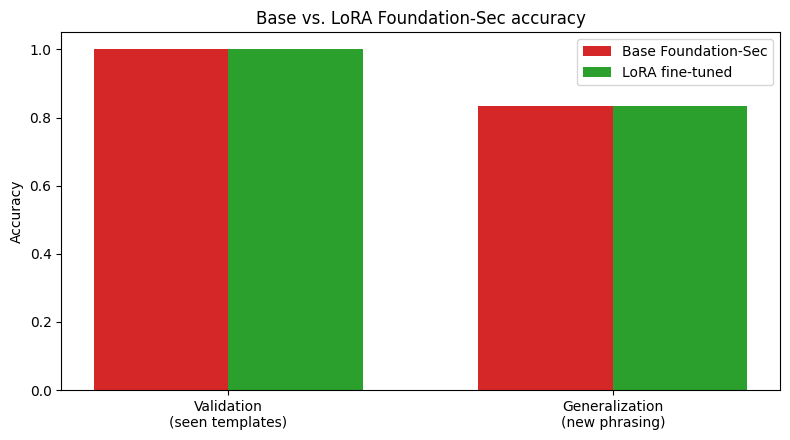

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
categories = ["Validation\n(seen templates)", "Generalization\n(new phrasing)"]
base_scores = [base_val_accuracy, base_gen_accuracy]
lora_scores = [lora_val_accuracy, lora_gen_accuracy]
x = np.arange(len(categories))
width = 0.35
ax.bar(x - width / 2, base_scores, width, label="Base Foundation-Sec", color="tab:red")
ax.bar(x + width / 2, lora_scores, width, label="LoRA fine-tuned", color="tab:green")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Base vs. LoRA Foundation-Sec accuracy")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "security_finetuning_mlx_comparison.png", dpi=150)
plt.show()

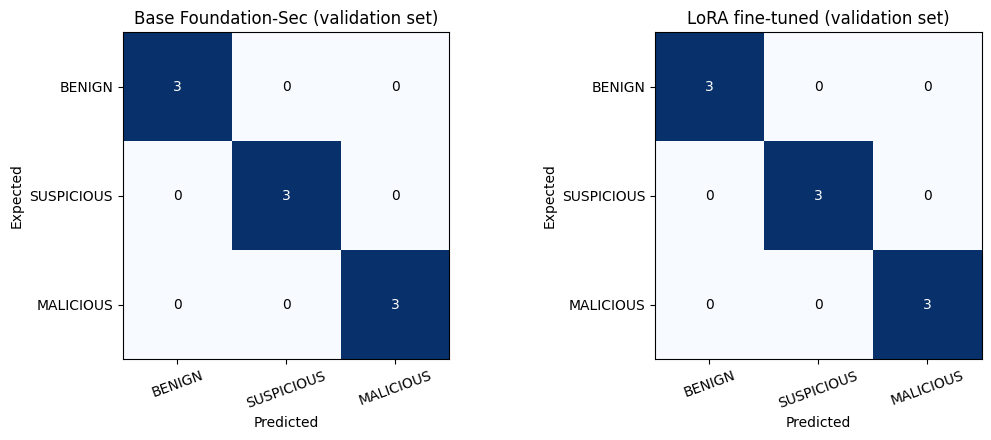

Saved: security_finetuning_mlx_loss.png, security_finetuning_mlx_comparison.png, security_finetuning_mlx_confusion_matrix.png
(Distinct filenames from notebook 06's finetuning_*.png -- both experiments' results are preserved side by side.)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cm, title in zip(axes, [cm_base, cm_lora], ["Base Foundation-Sec", "LoRA fine-tuned"]):
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(LABELS)))
    ax.set_yticks(range(len(LABELS)))
    ax.set_xticklabels(LABELS, rotation=20)
    ax.set_yticklabels(LABELS)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Expected")
    ax.set_title(f"{title} (validation set)")
    for i in range(len(LABELS)):
        for j in range(len(LABELS)):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "security_finetuning_mlx_confusion_matrix.png", dpi=150)
plt.show()

print("Saved: security_finetuning_mlx_loss.png, security_finetuning_mlx_comparison.png, security_finetuning_mlx_confusion_matrix.png")
print("(Distinct filenames from notebook 06's finetuning_*.png -- both experiments' results are preserved side by side.)")

## Final summary

**The key lesson is the same as notebook 06's: fine-tuning is not automatically the right answer, regardless of which model it's applied to.** What this notebook adds is a direct, verified answer to "could we have just fine-tuned the real security model instead": yes, via MLX rather than the `transformers`/`peft`/`bitsandbytes` path that doesn't yet support Apple Silicon for this, and yes within this Mac's 16GB -- but getting there required verifying, in order: that the standard path was actually blocked (not assumed), that a community MLX conversion of the *instruction-tuned* model existed and had a working chat template (the first one found was the base model and didn't), that LoRA injection produced a sane trainable-parameter count (the first attempt didn't, due to a real bug), and that training and evaluation actually ran end to end. Every one of those checks could have failed and changed the answer -- which is itself the point: "is it possible" is a question with a real, checkable answer, not a guess, and this notebook is the record of actually checking it rather than assuming either way.